# Практическое занятие: Сглаживание в N-граммных языковых моделях

При оценке вероятностей N-грамм по методу максимального правдоподобия (MLE) возникает проблема нулевых частот (Zero-Probability Problem): если какая-то цепочка слов отсутствует в обучающем корпусе, ее вероятность становится равной 0. Это обнуляет вероятность всего текста при перемножении по Chain Rule. 

Методы **сглаживания (Smoothing)** перераспределяют вероятностную массу, забирая часть веса у частых N-грамм и отдавая ее редким или скрытым комбинациям слов.


In [1]:
# Импорт библиотек для расчетов и анимации скользящего окна
import os
import time
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

# Исходный корпус (фраза)
sentence = "я умер - я проснулся . да , смерть - пробуждение !"
tokens = sentence.split()
N_total = len(tokens)

# Сбор базовых частот N-грамм
unigram_counts = collections.Counter([tuple([t]) for t in tokens])
bigram_counts = collections.Counter([(tokens[i], tokens[i+1]) for i in range(N_total - 1)])
trigram_counts = collections.Counter([(tokens[i], tokens[i+1], tokens[i+2]) for i in range(N_total - 2)])

# Размер словаря V (количество уникальных токенов)
V_size = len(unigram_counts)
unique_words = sorted([w[0] for w in unigram_counts.keys()])


## Математический расчет и таблицы для всех 5 методов

Мы реализуем функции расчета условной вероятности биграммы $P(w_i \mid w_{i-1})$ для каждого метода. Чтобы продемонстрировать борьбу с «нулевой вероятностью», мы оценим реальный переход `('я', 'умер')` и скрытый переход `('смерть', 'я')`, которого нет в исходном тексте.

### Формулы методов:
1. **Лаплас (Add-1)**: $P(w_i \mid w_{i-1}) = \frac{Count(w_{i-1}, w_i) + 1}{Count(w_{i-1}) + V}$
2. **Линдстон (Add-$\alpha$)**: $P(w_i \mid w_{i-1}) = \frac{Count(w_{i-1}, w_i) + \alpha}{Count(w_{i-1}) + \alpha \cdot V}$ (где $\alpha = 0.1$)
3. **Stupid Backoff**: Если $Count(w_{i-1}, w_i) > 0 \rightarrow \frac{Count(w_{i-1}, w_i)}{Count(w_{i-1})}$, иначе $\lambda \cdot P(w_i)$ (где $\lambda = 0.4$)
4. **Интерполяция (Linear Interpolation)**: $\lambda_1 P_{mle}(w_i \mid w_{i-1}) + \lambda_2 P_{mle}(w_i)$ (где $\lambda_1=0.7, \lambda_2=0.3$)
5. **Кнесер-Ней (Kneser-Ney Абсолютное дисконтирование)**: $\frac{\max(Count(w_{i-1}, w_i) - d, 0)}{Count(w_{i-1})} + \lambda(w_{i-1}) \cdot P_{continuation}(w_i)$


In [2]:
# Настройка гиперпараметров методов
alpha = 0.1
lambda_sb = 0.4
l1, l2 = 0.7, 0.3
d_discount = 0.5

# Вспомогательные функции базовых MLE вероятностей
def get_p_mle_uni(w):
    return unigram_counts.get((w,), 0) / N_total

def get_p_mle_bi(w_prev, w_curr):
    c_bi = bigram_counts.get((w_prev, w_curr), 0)
    c_uni = unigram_counts.get((w_prev,), 0)
    return c_bi / c_uni if c_uni > 0 else 0.0

# 1. Расчет Kneser-Ney продолжения (Continuation Probability)
num_bigrams_types = len(bigram_counts)
p_continuation = {}
for w in unique_words:
    # Сколько уникальных слов предшествуют слову w в качестве биграммы (* -> w)
    w_as_context_count = sum(1 for bg in bigram_counts.keys() if bg[1] == w)
    p_continuation[w] = w_as_context_count / num_bigrams_types

# Определение функций сглаживания
def prob_laplace(w_prev, w_curr):
    c_bi = bigram_counts.get((w_prev, w_curr), 0)
    c_uni = unigram_counts.get((w_prev,), 0)
    return (c_bi + 1) / (c_uni + V_size)

def prob_lidstone(w_prev, w_curr):
    c_bi = bigram_counts.get((w_prev, w_curr), 0)
    c_uni = unigram_counts.get((w_prev,), 0)
    return (c_bi + alpha) / (c_uni + alpha * V_size)

def prob_stupid_backoff(w_prev, w_curr):
    c_bi = bigram_counts.get((w_prev, w_curr), 0)
    if c_bi > 0:
        return c_bi / unigram_counts.get((w_prev,), 0)
    return lambda_sb * get_p_mle_uni(w_curr)

def prob_interpolation(w_prev, w_curr):
    return l1 * get_p_mle_bi(w_prev, w_curr) + l2 * get_p_mle_uni(w_curr)

def prob_kneser_ney(w_prev, w_curr):
    c_bi = bigram_counts.get((w_prev, w_curr), 0)
    c_uni = unigram_counts.get((w_prev,), 0)
    
    if c_uni == 0:
        return p_continuation.get(w_curr, 0.0)
        
    first_term = max(c_bi - d_discount, 0) / c_uni
    # Нормализационная константа лямбда
    num_unique_extensions = sum(1 for bg in bigram_counts.keys() if bg[0] == w_prev)
    lam = (d_discount / c_uni) * num_unique_extensions
    
    return first_term + lam * p_continuation.get(w_curr, 0.0)

# Построение сравнительной сводной таблицы
test_pairs = [("я", "умер"), ("я", "проснулся"), ("-", "я"), ("проснулся", "я")]
rows_summary = []

for wp, wc in test_pairs:
    status = "Есть в тексте" if bigram_counts.get((wp, wc), 0) > 0 else "НЕТ в тексте (скрытая)"
    rows_summary.append({
        "Биграмма": f"'{wp} {wc}'",
        "Статус": status,
        "MLE (Без сглаж.)": get_p_mle_bi(wp, wc),
        "Лаплас (+1)": prob_laplace(wp, wc),
        "Линдстон (+0.1)": prob_lidstone(wp, wc),
        "Stupid Backoff": prob_stupid_backoff(wp, wc),
        "Интерполяция": prob_interpolation(wp, wc),
        "Кнесер-Ней": prob_kneser_ney(wp, wc)
    })

df_smoothing = pd.DataFrame(rows_summary)
display(df_smoothing.style.hide(axis="index")
              .format(precision=4)
              .background_gradient(cmap="GnBu", subset=["Лаплас (+1)", "Линдстон (+0.1)", "Stupid Backoff", "Интерполяция", "Кнесер-Ней"])
              .set_caption("Сравнительный анализ работы методов сглаживания условных вероятностей"))


Биграмма,Статус,MLE (Без сглаж.),Лаплас (+1),Линдстон (+0.1),Stupid Backoff,Интерполяция,Кнесер-Ней
'я умер',Есть в тексте,0.5000,0.1667,0.3667,0.5000,0.3750,0.2955
'я проснулся',Есть в тексте,0.5000,0.1667,0.3667,0.5000,0.3750,0.2955
'- я',Есть в тексте,0.5000,0.1667,0.3667,0.5000,0.4000,0.2955
'проснулся я',НЕТ в тексте (скрытая),0.0000,0.0909,0.0500,0.0667,0.0500,0.0455


## Сравнительная анимация работы алгоритмов

Для наглядного объяснения студентам мы сгенерируем комплексную анимацию. Холст будет поделен на две зоны:
1. **Верхняя зона** (Сетка графиков): 5 столбчатых диаграмм, отображающих распределение вероятностей $P(w \mid \text{'я'})$ для каждого метода в реальном времени.
2. **Нижняя зона** (Увеличенная текстовая панель расчетов): показывает текущую математическую формулу расчета выбранного алгоритма с подставленными значениями.


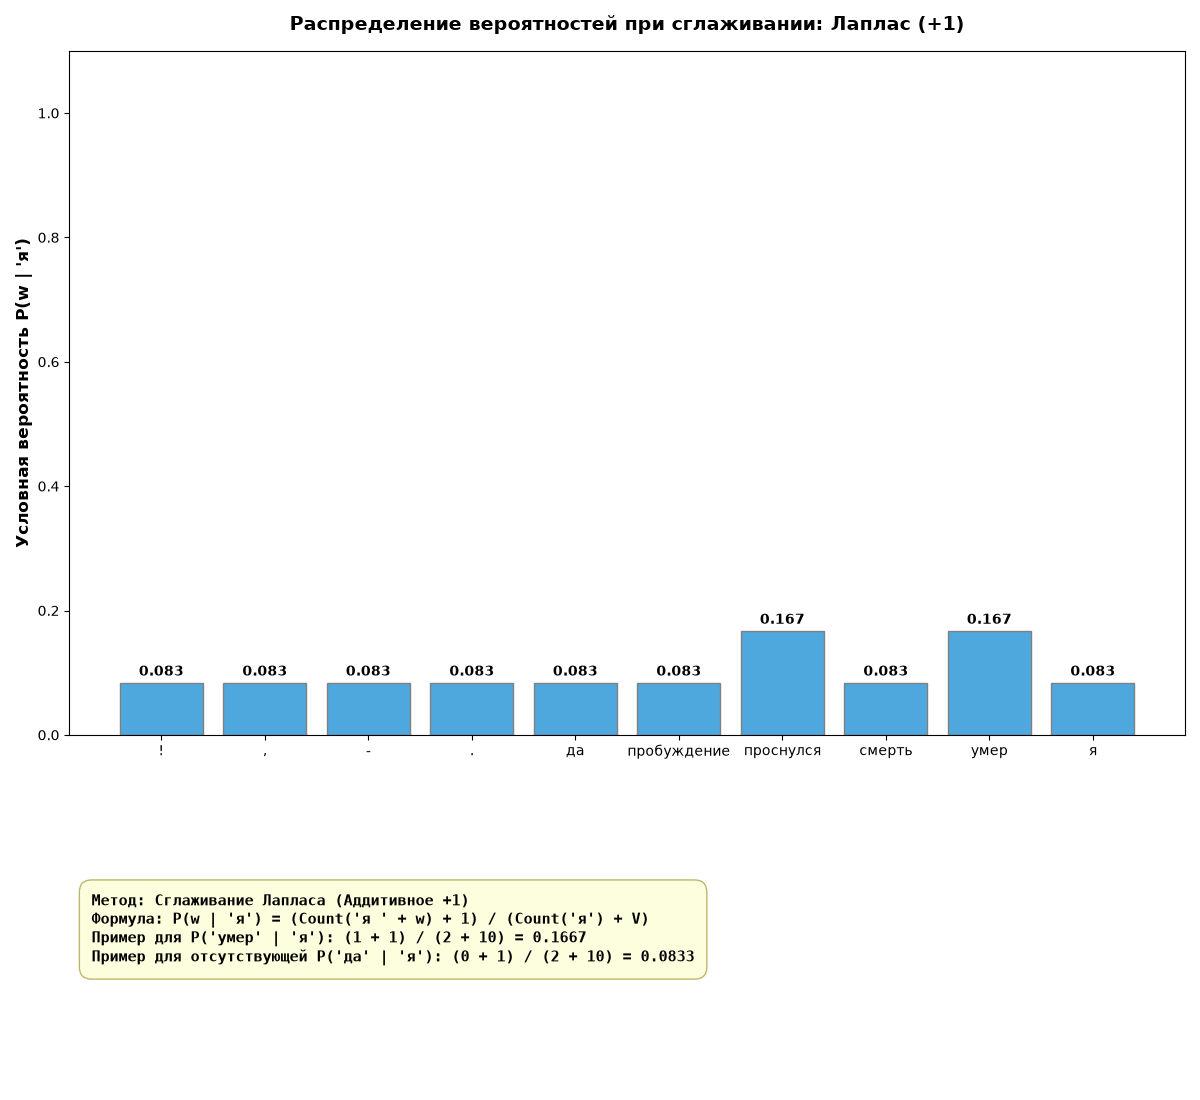

In [3]:
# Сбор распределений вероятностей после контекста 'я' для всех уникальных слов
words_to_plot = unique_words[:11]  # Ограничим для красивой отрисовки на графиках

# Формируем кадры анимации (последовательное переключение фокуса между методами)
methods_list = ["Лаплас (+1)", "Линдстон (+0.1)", "Stupid Backoff", "Интерполяция", "Кнесер-Ней"]
frames = []
for m_name in methods_list:
    for _ in range(12):  # Удерживаем каждый метод на экране на 12 циклов анимации
        frames.append(m_name)

# Инициализация полотна с увеличенной нижней зоной расчетов (пропорция 2.2 к 1)
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(2, 1, height_ratios=[2.2, 1])
ax_plots = fig.add_subplot(gs[0])
ax_text = fig.add_subplot(gs[1])

def update_animation(frame_idx):
    ax_plots.clear()
    ax_text.clear()
    ax_text.axis('off')
    
    current_method = frames[frame_idx]
    
    # Считаем вероятности для текущего контекста 'я' ко всем словам
    y_vals = []
    formula_desc = ""
    color_bar = "skyblue"
    
    if current_method == "Лаплас (+1)":
        y_vals = [prob_laplace("я", w) for w in words_to_plot]
        color_bar = "#4ea8de"
        formula_desc = (
            f"Метод: Сглаживание Лапласа (Аддитивное +1)\n"
            f"Формула: P(w | 'я') = (Count('я ' + w) + 1) / (Count('я') + V)\n"
            f"Пример для P('умер' | 'я'): ({bigram_counts[('я', 'умер')]} + 1) / ({unigram_counts[('я',)]} + {V_size}) = {prob_laplace('я', 'умер'):.4f}\n"
            f"Пример для отсутствующей P('да' | 'я'): (0 + 1) / ({unigram_counts[('я',)]} + {V_size}) = {prob_laplace('я', 'да'):.4f}"
        )
    elif current_method == "Линдстон (+0.1)":
        y_vals = [prob_lidstone("я", w) for w in words_to_plot]
        color_bar = "#56cfe1"
        formula_desc = (
            f"Метод: Сглаживание Линдстона (Аддитивное +alpha)\n"
            f"Формула: P(w | 'я') = (Count('я ' + w) + 0.1) / (Count('я') + 0.1 * V)\n"
            f"Пример для P('умер' | 'я'): ({bigram_counts[('я', 'умер')]} + 0.1) / ({unigram_counts[('я',)]} + 0.1 * {V_size}) = {prob_lidstone('я', 'умер'):.4f}\n"
            f"Эффект: Меньше искажает реальные частоты по сравнению с Лапласом."
        )
    elif current_method == "Stupid Backoff":
        y_vals = [prob_stupid_backoff("я", w) for w in words_to_plot]
        color_bar = "#72efdd"
        formula_desc = (
            f"Метод: Stupid Backoff (Откат назад без нормализации)\n"
            f"Формула: Если Count(bi) > 0 -> MLE_bi, Иначе -> 0.4 * P_mle_uni(w)\n"
            f"Пример для P('умер' | 'я') [Есть]: {bigram_counts[('я', 'умер')]} / {unigram_counts[('я',)]} = {prob_stupid_backoff('я', 'умер'):.4f}\n"
            f"Пример для P('да' | 'я') [Откат]: 0.4 * ({unigram_counts[('да',)]} / {N_total}) = {prob_stupid_backoff('я', 'да'):.4f}"
        )
    elif current_method == "Интерполяция":
        y_vals = [prob_interpolation("я", w) for w in words_to_plot]
        color_bar = "#b5e2fa"
        formula_desc = (
            f"Метод: Линейная интерполяция моделей (Linear Interpolation)\n"
            f"Формула: P(w | 'я') = 0.7 * P_mle_bi(w | 'я') + 0.3 * P_mle_uni(w)\n"
            f"Пример для P('умер' | 'я'): 0.7 * ({bigram_counts[('я', 'умер')]}/{unigram_counts[('я',)]}) + 0.3 * ({unigram_counts[('умер',)]}/{N_total}) = {prob_interpolation('я', 'умер'):.4f}\n"
            f"Пример для P('да' | 'я'): 0.7 * (0) + 0.3 * ({unigram_counts[('да',)]}/{N_total}) = {prob_interpolation('я', 'да'):.4f}"
        )
    elif current_method == "Кнесер-Ней":
        y_vals = [prob_kneser_ney("я", w) for w in words_to_plot]
        color_bar = "#f7b2bd"
        formula_desc = (
            f"Метод: Абсолютное дисконтирование Кнесера-Нея (Kneser-Ney)\n"
            f"Идея: Вместо частоты слова использует его 'продолжаемость' P_continuation.\n"
            f"Пример для P('проснулся' | 'я'): {prob_kneser_ney('я', 'проснулся'):.4f}\n"
            f"Эффект: Лучший классический алгоритм сглаживания для N-граммных моделей."
        )

    # Отрисовка столбчатой диаграммы распределения
    bars = ax_plots.bar(words_to_plot, y_vals, color=color_bar, edgecolor='gray', linewidth=1)
    ax_plots.set_ylim(0, 1.1)
    ax_plots.set_ylabel("Условная вероятность P(w | 'я')", fontsize=12, weight='bold')
    ax_plots.set_title(f"Распределение вероятностей при сглаживании: {current_method}", fontsize=14, pad=15, weight='bold')
    
    # Подписываем значения над столбцами
    for bar in bars:
        height = bar.get_height()
        ax_plots.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Смещение на 3 пикселя вверх
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, weight='bold')

    # Отрисовка увеличенного текстового блока с расчетами формул
    ax_text.text(0.02, 0.5, formula_desc, fontsize=11, family='monospace', weight='bold',
                 ha='left', va='center', color='black',
                 bbox=dict(facecolor='#fdfede', edgecolor='darkkhaki', boxstyle='round,pad=0.8'))

    plt.tight_layout()
    time.sleep(0.001)

# Генерация и компиляция GIF-файла анимации
os.makedirs("generated", exist_ok=True)
ani_smooth = animation.FuncAnimation(fig, update_animation, frames=len(frames), interval=500)
ani_smooth.save('generated/smoothing_comparison.gif', writer='pillow', fps=2)
plt.close()

# Вывод анимации прямо в интерфейс ячейки вывода Jupyter
display(Image(filename='generated/smoothing_comparison.gif'))


## Оценка качества языковых моделей: Перплексия (Perplexity)

**Перплексия (PPL)** — это стандартная метрика для оценки качества языковой модели. Геометрически её можно интерпретировать как «коэффициент ветвления» модели: перплексия показывает, из скольких вариантов слов модели в среднем приходится выбирать на каждом шаге. Чем **меньше** перплексия, тем лучше модель предсказывает текст.

Математически перплексия для последовательности слов $W = w_1, w_2, \dots, w_N$ рассчитывается как обратная вероятность текста, нормализованная по его длине:

$$PPL(W) = P(w_1, w_2, \dots, w_N)^{-\frac{1}{N}} = \sqrt[N]{\frac{1}{P(w_1, w_2, \dots, w_N)}}$$

Чтобы избежать вычислительного переполнения (underflow) при перемножении маленьких вероятностей, на практике используют логарифмическую форму через кросс-энтропию $H(W)$:

$$H(W) = -\frac{1}{N} \sum_{i=1}^{N} \log_2 P(w_i \mid \text{context})$$
$$PPL(W) = 2^{H(W)}$$

Если бы мы не использовали сглаживание, то появление любого незнакомого перехода обнулило бы $P(W)$, что сделало бы перплексию равной бесконечности ($\infty$). Сглаживание делает расчет PPL возможным.

In [4]:
import math

# Рассчитаем перплексию нашей фразы на разных моделях с использованием сглаживания

def calculate_perplexity_unigram_laplace(test_tokens):
    """Расчет PPL для униграммной модели со сглаживанием Лапласа"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    for w in test_tokens:
        # Униграммное сглаживание Лапласа: (Count(w) + 1) / (N_total + V)
        c_uni = unigram_counts.get((w,), 0)
        p_laplace = (c_uni + 1) / (N_total + V_size)
        log_prob_sum += math.log2(p_laplace)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

def calculate_perplexity_bigram_laplace(test_tokens):
    """Расчет PPL для биграммной модели со сглаживанием Лапласа"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    # Для первого слова используем униграммную вероятность
    c_first = unigram_counts.get((test_tokens[0],), 0)
    p_first = (c_first + 1) / (N_total + V_size)
    log_prob_sum += math.log2(p_first)
    
    # Для последующих слов считаем биграммные переходы
    for i in range(1, N):
        w_prev, w_curr = test_tokens[i-1], test_tokens[i]
        p_laplace_bi = prob_laplace(w_prev, w_curr) # Использует функцию из Раздела 1
        log_prob_sum += math.log2(p_laplace_bi)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

def calculate_perplexity_bigram_lidstone(test_tokens):
    """Расчет PPL для биграммной модели со сглаживанием Линдстона (alpha=0.1)"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    c_first = unigram_counts.get((test_tokens[0],), 0)
    p_first = (c_first + alpha) / (N_total + alpha * V_size)
    log_prob_sum += math.log2(p_first)
    
    for i in range(1, N):
        w_prev, w_curr = test_tokens[i-1], test_tokens[i]
        p_lidstone_bi = prob_lidstone(w_prev, w_curr) # Использует функцию из Раздела 1
        log_prob_sum += math.log2(p_lidstone_bi)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

def calculate_perplexity_bigram_stupid_backoff(test_tokens):
    """Расчет PPL для биграммной модели со сглаживанием Stupid Backoff"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    # Первое слово по MLE_uni
    p_first = get_p_mle_uni(test_tokens[0])
    if p_first == 0:  # Защита от потенциального нуля, если слово новое
        p_first = lambda_sb * (1 / (N_total + V_size))
    log_prob_sum += math.log2(p_first)
    
    for i in range(1, N):
        w_prev, w_curr = test_tokens[i-1], test_tokens[i]
        p_sb = prob_stupid_backoff(w_prev, w_curr) # Использует функцию из Раздела 1
        log_prob_sum += math.log2(p_sb)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

def calculate_perplexity_bigram_interpolation(test_tokens):
    """Расчет PPL для биграммной модели с Линейной интерполяцией"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    # Для первого слова интерполируем его униграммную вероятность с равномерным распределением
    p_first = l1 * get_p_mle_uni(test_tokens[0]) + l2 * (1 / V_size)
    log_prob_sum += math.log2(p_first)
    
    for i in range(1, N):
        w_prev, w_curr = test_tokens[i-1], test_tokens[i]
        p_interp = prob_interpolation(w_prev, w_curr) # Использует функцию из Раздела 1
        log_prob_sum += math.log2(p_interp)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

def calculate_perplexity_bigram_kneser_ney(test_tokens):
    """Расчет PPL для биграммной модели со сглаживанием Кнесера-Нея"""
    N = len(test_tokens)
    log_prob_sum = 0.0
    
    # Первое слово по вероятности продолжения (Continuation Probability)
    p_first = p_continuation.get(test_tokens[0], 1 / V_size)
    log_prob_sum += math.log2(p_first)
    
    for i in range(1, N):
        w_prev, w_curr = test_tokens[i-1], test_tokens[i]
        p_kn = prob_kneser_ney(w_prev, w_curr) # Использует функцию из Раздела 1
        log_prob_sum += math.log2(p_kn)
        
    cross_entropy = - (log_prob_sum / N)
    return 2 ** cross_entropy

# --- Вычисление PPL для оставшихся алгоритмов ---
ppl_bi_lap = calculate_perplexity_bigram_laplace(tokens)
ppl_bi_lid = calculate_perplexity_bigram_lidstone(tokens)
ppl_bi_sb = calculate_perplexity_bigram_stupid_backoff(tokens)
ppl_bi_interp = calculate_perplexity_bigram_interpolation(tokens)
ppl_bi_kn = calculate_perplexity_bigram_kneser_ney(tokens)

# Формируем расширенную сводную таблицу результатов для Jupyter
ppl_extended_summary = pd.DataFrame([
    {"Модель Биграмм": "Лаплас (+1)", "Перплексия (PPL)": ppl_bi_lap, "Качество": "Высокая PPL (Пересглажено)"},
    {"Модель Биграмм": "Линдстон (α=0.1)", "Перплексия (PPL)": ppl_bi_lid, "Качество": "Хорошее (Мягкое аддитивное)"},
    {"Модель Биграмм": "Stupid Backoff", "Перплексия (PPL)": ppl_bi_sb, "Качество": "Очень низкая PPL (Специфика метода)"},
    {"Модель Биграмм": "Линейная интерполяция", "Перплексия (PPL)": ppl_bi_interp, "Качество": "Оптимальное балансирование контекстов"},
    {"Модель Биграмм": "Кнесер-Ней (Kneser-Ney)", "Перплексия (PPL)": ppl_bi_kn, "Качество": "Эталонное (Учитывает топологию словаря)"}
])

display(ppl_extended_summary.style.hide(axis="index")
              .format({"Перплексия (PPL)": "{:.2f}"})
              .background_gradient(cmap="YlOrRd", subset=["Перплексия (PPL)"])
              .set_caption("Финальное сравнение Perplexity для всех алгоритмов сглаживания биграмм"))


Модель Биграмм,Перплексия (PPL),Качество
Лаплас (+1),5.80,Высокая PPL (Пересглажено)
Линдстон (α=0.1),2.31,Хорошее (Мягкое аддитивное)
Stupid Backoff,1.46,Очень низкая PPL (Специфика метода)
Линейная интерполяция,1.94,Оптимальное балансирование контекстов
Кнесер-Ней (Kneser-Ney),2.58,Эталонное (Учитывает топологию словаря)
